# Whole-session participant bootstrap

This notebook estimates group-level agreement across sensor placements using participant-level whole-session Pearson correlations and bootstrap confidence intervals.

For each physiological signal (EDA and PPG-derived HR) and each of the six device-placement comparisons:

1. The complete experimental interval is cropped from `full_test_start` to `full_test_end`.
2. The two signals are temporally aligned for each participant.
3. A single Pearson correlation $r_i$ is computed for each participant using the entire aligned interval.
4. Participant-specific correlations are Fisher-$z$ transformed.
5. Participants are resampled with replacement and the mean Fisher-$z$ is calculated for each bootstrap sample.
6. The bootstrap estimates are transformed back to the correlation scale.
7. The group correlation and 95% percentile bootstrap confidence interval are reported.


In [7]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.stats import pearsonr

warnings.filterwarnings("ignore", category=RuntimeWarning)

# CONFIGURATION
PROCESSED_DATA_PATH = Path("processed_data/processed_data.pickle")
STAMPS_DIR = Path("data/Stamps")
OUTPUT_DIR = Path("results/bootstrap")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_BOOT = 5000
RNG_SEED = 20260904
MIN_VALID_SAMPLES = 20

PIPELINE_PATH = {
    "Gsr": ["IQR", "gaussian", "original", "df"],
    "Hr":  ["IQR", "butterworth", "original", "df"],
}

DEVICES = [
    "emotibit_volar",
    "emotibit_dorsal",
    "shimmer_wrist",
    "shimmer_fingers",
]

COMPARISONS = [
    ("emotibit_volar", "emotibit_dorsal"),
    ("shimmer_wrist", "shimmer_fingers"),
    ("emotibit_volar", "shimmer_wrist"),
    ("emotibit_volar", "shimmer_fingers"),
    ("emotibit_dorsal", "shimmer_wrist"),
    ("emotibit_dorsal", "shimmer_fingers"),
]

SIGNALS = ["Hr", "Gsr"]

ROW_LABELS = {
    ("emotibit_volar", "emotibit_dorsal"): "EmotiBit volar vs dorsal",
    ("shimmer_wrist", "shimmer_fingers"): "Shimmer wrist vs fingers",
    ("emotibit_volar", "shimmer_wrist"): "EmotiBit volar vs Shimmer wrist",
    ("emotibit_volar", "shimmer_fingers"): "EmotiBit volar vs Shimmer fingers",
    ("emotibit_dorsal", "shimmer_wrist"): "EmotiBit dorsal vs Shimmer wrist",
    ("emotibit_dorsal", "shimmer_fingers"): "EmotiBit dorsal vs Shimmer fingers",
}

print("Bootstrap iterations:", N_BOOT)


Bootstrap iterations: 5000


## 1. Load preprocessed data

The notebook uses the preprocessed dataset generated by `preprocessing.ipynb` and stored at the path defined by `PROCESSED_DATA_PATH`.


In [8]:

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"{PROCESSED_DATA_PATH} not found. "
        "Run preprocessing.ipynb first."
    )

with open(PROCESSED_DATA_PATH, "rb") as f:
    data = pickle.load(f)

participants = sorted(set.intersection(*[
    set(data[d].keys()) for d in DEVICES if d in data
]))

print("Participants:", participants)
print("N =", len(participants))


Participants: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
N = 10


## 2. Helpers for temporal alignment

The functions below load the selected processing branch, crop each recording to the complete experimental interval, and align each device pair on a common time axis before correlation analysis.


In [9]:

def nested_get(obj, path):
    out = obj
    for key in path:
        out = out[key]
    return out


def get_selected_df(device, user, signal):
    df = nested_get(data[device][user][signal], PIPELINE_PATH[signal]).copy()

    if "Timestamp" not in df.columns:
        raise KeyError(f"'Timestamp' missing for {device}/{user}/{signal}")

    return df


def infer_value_column(df):
    cols = [c for c in df.columns if c != "Timestamp"]
    numeric = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

    if not numeric:
        raise ValueError("No numeric signal column found.")

    return numeric[0]


def infer_fs(df):
    t = np.sort(df["Timestamp"].dropna().unique())
    if len(t) < 3:
        return np.nan

    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]

    if len(dt) == 0:
        return np.nan

    return float(1.0 / np.median(dt))


def get_full_test_bounds(user):
    path = STAMPS_DIR / f"{user}.txt"
    ev = pd.read_csv(path, header=None, names=["Event", "Timestamp"])

    starts = ev.loc[ev["Event"] == "full_test_start", "Timestamp"].values
    ends = ev.loc[ev["Event"] == "full_test_end", "Timestamp"].values

    if len(starts) == 0 or len(ends) == 0:
        raise KeyError(f"Missing full_test_start/full_test_end for participant {user}")

    return float(starts[0]), float(ends[0])


def align_whole_session(user, signal, dev1, dev2):
    t0, t1 = get_full_test_bounds(user)

    df1 = get_selected_df(dev1, user, signal)
    df2 = get_selected_df(dev2, user, signal)

    df1 = df1[(df1["Timestamp"] >= t0) & (df1["Timestamp"] <= t1)].copy()
    df2 = df2[(df2["Timestamp"] >= t0) & (df2["Timestamp"] <= t1)].copy()

    if df1.empty or df2.empty:
        return None

    c1 = infer_value_column(df1)
    c2 = infer_value_column(df2)

    d1 = (
        df1[["Timestamp", c1]]
        .dropna()
        .drop_duplicates("Timestamp")
        .sort_values("Timestamp")
    )
    d2 = (
        df2[["Timestamp", c2]]
        .dropna()
        .drop_duplicates("Timestamp")
        .sort_values("Timestamp")
    )

    if len(d1) < 2 or len(d2) < 2:
        return None

    lo = max(d1["Timestamp"].min(), d2["Timestamp"].min())
    hi = min(d1["Timestamp"].max(), d2["Timestamp"].max())

    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        return None

    fs_candidates = [infer_fs(d1), infer_fs(d2)]
    fs_candidates = [f for f in fs_candidates if np.isfinite(f) and f > 0]

    if not fs_candidates:
        return None

    # Use the lower observed rate to avoid unnecessary upsampling.
    target_fs = min(fs_candidates)

    n_points = int(np.floor((hi - lo) * target_fs)) + 1
    if n_points < MIN_VALID_SAMPLES:
        return None

    common_time = np.linspace(lo, hi, n_points)

    f1 = interp1d(
        d1["Timestamp"].to_numpy(),
        d1[c1].to_numpy(dtype=float),
        kind="nearest",
        bounds_error=False,
        fill_value=np.nan,
    )

    f2 = interp1d(
        d2["Timestamp"].to_numpy(),
        d2[c2].to_numpy(dtype=float),
        kind="nearest",
        bounds_error=False,
        fill_value=np.nan,
    )

    x = np.asarray(f1(common_time), dtype=float)
    y = np.asarray(f2(common_time), dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]
    common_time = common_time[valid]

    if len(x) < MIN_VALID_SAMPLES:
        return None

    if np.std(x) == 0 or np.std(y) == 0:
        return None

    return {
        "participant": user,
        "signal": signal,
        "dev1": dev1,
        "dev2": dev2,
        "x": x,
        "y": y,
        "time": common_time,
        "fs": target_fs,
    }


## 3. Participant-level whole-session Pearson correlations

For each participant and device-placement comparison, a single Pearson correlation is computed using the complete aligned experimental interval.

Participant-specific Pearson $p$-values are not used for group inference because the time samples within each participant are serially dependent. Group-level uncertainty is instead estimated by resampling participants in the bootstrap analysis below.


In [10]:

def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < MIN_VALID_SAMPLES:
        return np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan

    return float(pearsonr(x, y).statistic)


participant_rows = []
aligned_cache = {}

for signal in SIGNALS:
    for pair in COMPARISONS:
        aligned_cache[(signal, pair)] = {}

        for user in participants:
            item = align_whole_session(
                user=user,
                signal=signal,
                dev1=pair[0],
                dev2=pair[1],
            )

            if item is None:
                continue

            aligned_cache[(signal, pair)][user] = item

            r = safe_pearson_r(item["x"], item["y"])
            bias = float(np.mean(item["x"] - item["y"]))

            participant_rows.append({
                "signal": signal,
                "comparison": ROW_LABELS[pair],
                "dev1": pair[0],
                "dev2": pair[1],
                "participant": user,
                "r": r,
                "bias": bias,
                "n_time_samples": len(item["x"]),
            })

participant_df = pd.DataFrame(participant_rows)

participant_df.to_csv(
    OUTPUT_DIR / "participant_whole_session_correlations.csv",
    index=False
)

display(participant_df.head())


,signal,comparison,dev1,dev2,participant,r,bias,n_time_samples
0,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,1,0.565012,-9.833322,716
1,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,10,0.938502,-0.354714,582
2,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,2,0.929632,2.884092,595
3,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,3,0.677721,-11.673959,501
4,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,4,0.804746,-6.307622,572


## 4. Participant bootstrap

The bootstrap resamples participants with replacement for `N_BOOT` iterations. The random seed is fixed to make the analysis reproducible.


In [11]:

def fisher_z(r):
    eps = 1e-7
    return np.arctanh(np.clip(r, -1 + eps, 1 - eps))


def fisher_mean_r(r_values):
    r_values = np.asarray(r_values, dtype=float)
    r_values = r_values[np.isfinite(r_values)]

    if len(r_values) == 0:
        return np.nan

    return float(np.tanh(np.mean(fisher_z(r_values))))


def participant_bootstrap(r_values, n_boot=N_BOOT, seed=RNG_SEED):
    """Resample participant-level correlation values with replacement."""

    r_values = np.asarray(r_values, dtype=float)
    r_values = r_values[np.isfinite(r_values)]

    n = len(r_values)

    if n < 2:
        return None

    rng = np.random.default_rng(seed)

    z = fisher_z(r_values)

    point_estimate = float(np.tanh(np.mean(z)))

    boot_r = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        sampled_z = rng.choice(z, size=n, replace=True)
        boot_r[b] = np.tanh(np.mean(sampled_z))

    ci_low, ci_high = np.quantile(
        boot_r,
        [0.025, 0.975]
    )

    return {
        "n_participants": n,
        "group_r": point_estimate,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "n_boot": n_boot,
        "bootstrap_distribution": boot_r,
    }


In [12]:
import hashlib

summary_rows = []
bootstrap_distributions = {}

for signal in SIGNALS:
    for pair in COMPARISONS:

        label = ROW_LABELS[pair]

        subset = participant_df[
            (participant_df["signal"] == signal) &
            (participant_df["dev1"] == pair[0]) &
            (participant_df["dev2"] == pair[1])
        ].copy()

        res = participant_bootstrap(
            subset["r"].to_numpy(),
            n_boot=N_BOOT,
            seed=RNG_SEED + int.from_bytes(
                hashlib.sha256(repr((signal, pair)).encode("utf-8")).digest()[:8],
                byteorder="big",
            ),
        )

        if res is None:
            continue

        mean_bias = float(subset["bias"].mean())

        summary_rows.append({
            "signal": signal,
            "comparison": label,
            "dev1": pair[0],
            "dev2": pair[1],
            "n_participants": res["n_participants"],
            "group_r": res["group_r"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
            "mean_bias": mean_bias,
            "n_boot": res["n_boot"],
        })

        bootstrap_distributions[(signal, label)] = res["bootstrap_distribution"]

summary_df = pd.DataFrame(summary_rows)

summary_df.to_csv(
    OUTPUT_DIR / "whole_session_bootstrap.csv",
    index=False
)

display(summary_df.round(4))


,signal,comparison,dev1,dev2,n_participants,group_r,ci_low,ci_high,mean_bias,n_boot
0,Hr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,10,0.8405,0.7247,0.9147,-2.5433,5000
1,Hr,Shimmer wrist vs fingers,shimmer_wrist,shimmer_fingers,10,0.4751,0.3169,0.6147,-3.4625,5000
2,Hr,EmotiBit volar vs Shimmer wrist,emotibit_volar,shimmer_wrist,10,0.6003,0.3314,0.7634,-12.7994,5000
3,Hr,EmotiBit volar vs Shimmer fingers,emotibit_volar,shimmer_fingers,10,0.5517,0.3715,0.6873,-16.2454,5000
4,Hr,EmotiBit dorsal vs Shimmer wrist,emotibit_dorsal,shimmer_wrist,10,0.5504,0.3029,0.7216,-10.2492,5000
5,Hr,EmotiBit dorsal vs Shimmer fingers,emotibit_dorsal,shimmer_fingers,10,0.5700,0.3362,0.7311,-13.6740,5000
6,Gsr,EmotiBit volar vs dorsal,emotibit_volar,emotibit_dorsal,10,0.9657,0.9340,0.9820,0.9237,5000
7,Gsr,Shimmer wrist vs fingers,shimmer_wrist,shimmer_fingers,10,0.7888,0.6887,0.8586,-3.0234,5000
8,Gsr,EmotiBit volar vs Shimmer wrist,emotibit_volar,shimmer_wrist,10,0.9374,0.8951,0.9620,0.0095,5000
9,Gsr,EmotiBit volar vs Shimmer fingers,emotibit_volar,shimmer_fingers,10,0.6980,0.5771,0.7978,-3.0140,5000


## 5. Visualize distributions

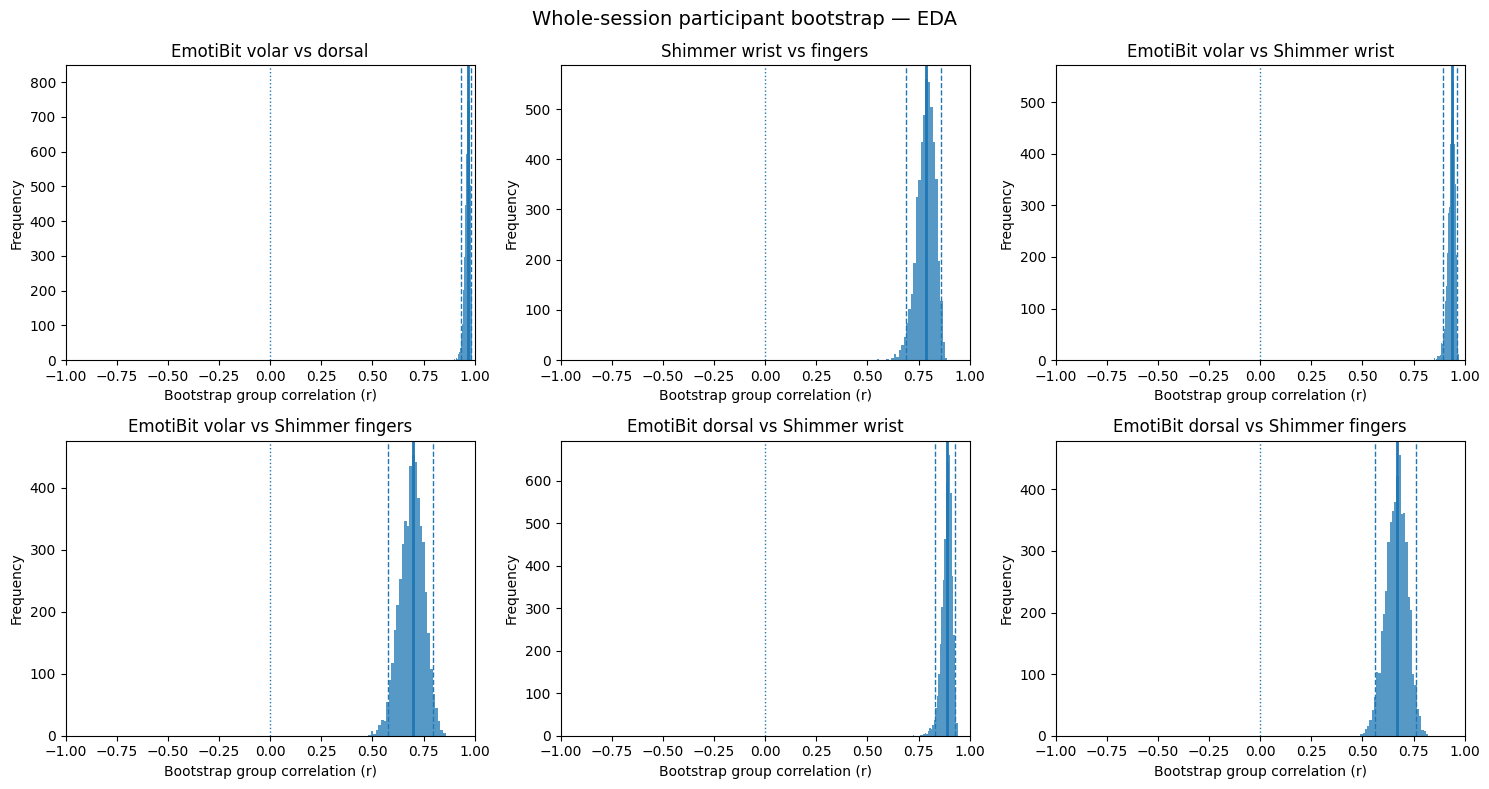

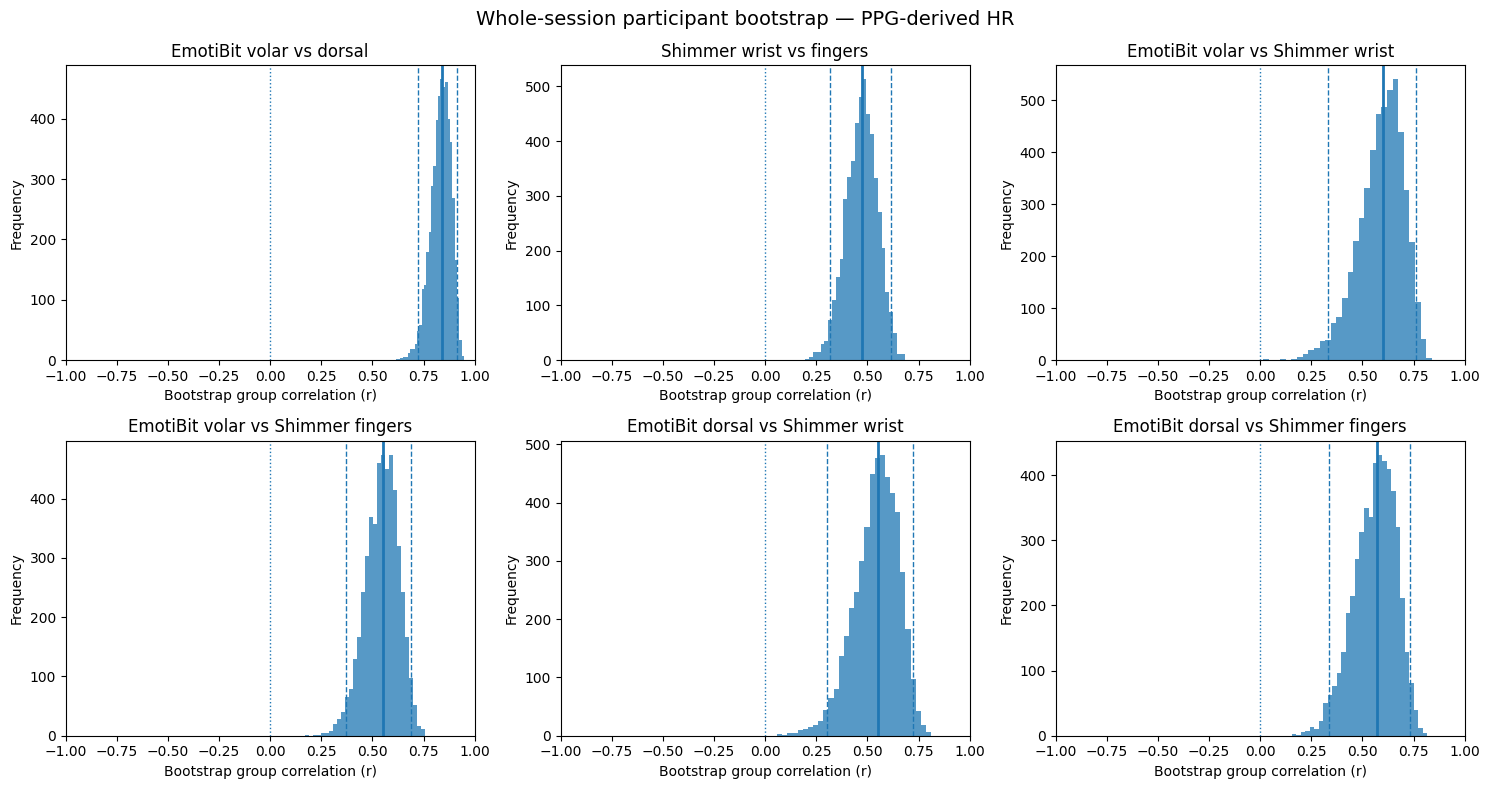

In [13]:

def plot_bootstrap_distributions(signal):
    signal_label = "PPG-derived HR" if signal == "Hr" else "EDA"

    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 8)
    )

    axes = axes.flatten()

    for ax, pair in zip(axes, COMPARISONS):

        label = ROW_LABELS[pair]
        dist = bootstrap_distributions[(signal, label)]

        row = summary_df[
            (summary_df["signal"] == signal) &
            (summary_df["comparison"] == label)
        ].iloc[0]

        ax.hist(
            dist,
            bins=30,
            alpha=0.75
        )

        ax.axvline(
            row["group_r"],
            linewidth=2,
            label=f'r = {row["group_r"]:.3f}'
        )

        ax.axvline(
            row["ci_low"],
            linestyle="--",
            linewidth=1
        )

        ax.axvline(
            row["ci_high"],
            linestyle="--",
            linewidth=1
        )

        ax.axvline(
            0,
            linestyle=":",
            linewidth=1
        )

        ax.set_title(label)
        ax.set_xlabel("Bootstrap group correlation (r)")
        ax.set_ylabel("Frequency")
        ax.set_xlim(-1, 1)

    fig.suptitle(
        f"Whole-session participant bootstrap — {signal_label}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


plot_bootstrap_distributions("Gsr")
plot_bootstrap_distributions("Hr")


## 6. Summary table

The following table combines the whole-session bootstrap estimates and mean bias values for PPG-derived HR and EDA across all device-placement comparisons.


In [14]:

table_rows = []

for pair in COMPARISONS:

    hr = summary_df[
        (summary_df["signal"] == "Hr") &
        (summary_df["dev1"] == pair[0]) &
        (summary_df["dev2"] == pair[1])
    ].iloc[0]

    eda = summary_df[
        (summary_df["signal"] == "Gsr") &
        (summary_df["dev1"] == pair[0]) &
        (summary_df["dev2"] == pair[1])
    ].iloc[0]

    table_rows.append({
        "Comparison": ROW_LABELS[pair],

        "HR mean Pearson r": hr["group_r"],
        "HR 95% CI": f'[{hr["ci_low"]:.3f}, {hr["ci_high"]:.3f}]',
        "HR mean bias (bpm)": hr["mean_bias"],

        "EDA mean Pearson r": eda["group_r"],
        "EDA 95% CI": f'[{eda["ci_low"]:.3f}, {eda["ci_high"]:.3f}]',
        "EDA mean bias (µS)": eda["mean_bias"],
    })

table_df = pd.DataFrame(table_rows)

table_df.to_csv(
    OUTPUT_DIR / "manuscript_table_bootstrap.csv",
    index=False
)

display(
    table_df.style.format({
        "HR mean Pearson r": "{:.3f}",
        "HR mean bias (bpm)": "{:.3f}",
        "EDA mean Pearson r": "{:.3f}",
        "EDA mean bias (µS)": "{:.3f}",
    })
)


,Comparison,HR mean Pearson r,HR 95% CI,HR mean bias (bpm),EDA mean Pearson r,EDA 95% CI,EDA mean bias (µS)
0,EmotiBit volar vs dorsal,0.841,"[0.725, 0.915]",-2.543,0.966,"[0.934, 0.982]",0.924
1,Shimmer wrist vs fingers,0.475,"[0.317, 0.615]",-3.463,0.789,"[0.689, 0.859]",-3.023
2,EmotiBit volar vs Shimmer wrist,0.600,"[0.331, 0.763]",-12.799,0.937,"[0.895, 0.962]",0.009
3,EmotiBit volar vs Shimmer fingers,0.552,"[0.372, 0.687]",-16.245,0.698,"[0.577, 0.798]",-3.014
4,EmotiBit dorsal vs Shimmer wrist,0.550,"[0.303, 0.722]",-10.249,0.890,"[0.831, 0.926]",-0.914
5,EmotiBit dorsal vs Shimmer fingers,0.570,"[0.336, 0.731]",-13.674,0.669,"[0.562, 0.760]",-3.938


## 7. Confidence-interval plots

These plots provide a compact visualization of the group correlation estimates and their 95% bootstrap confidence intervals.


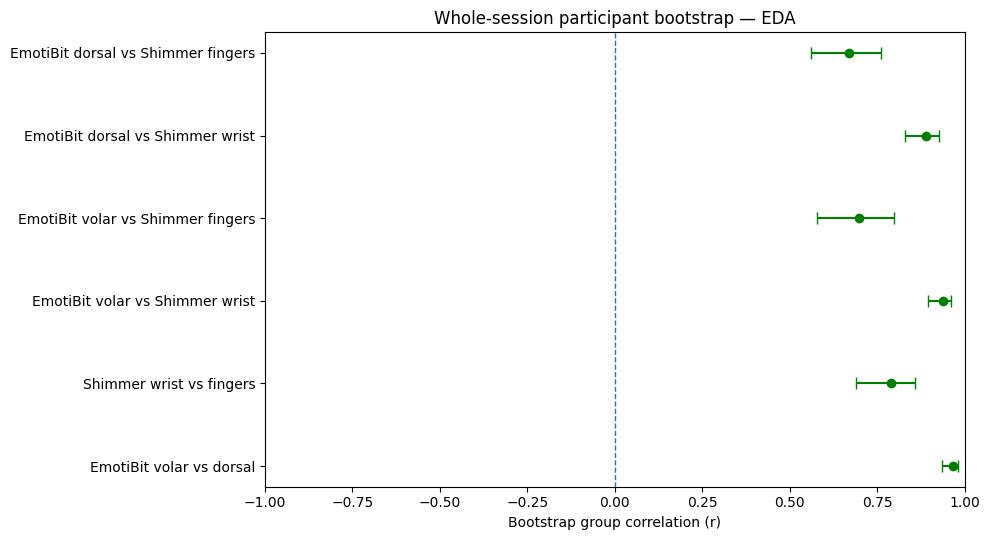

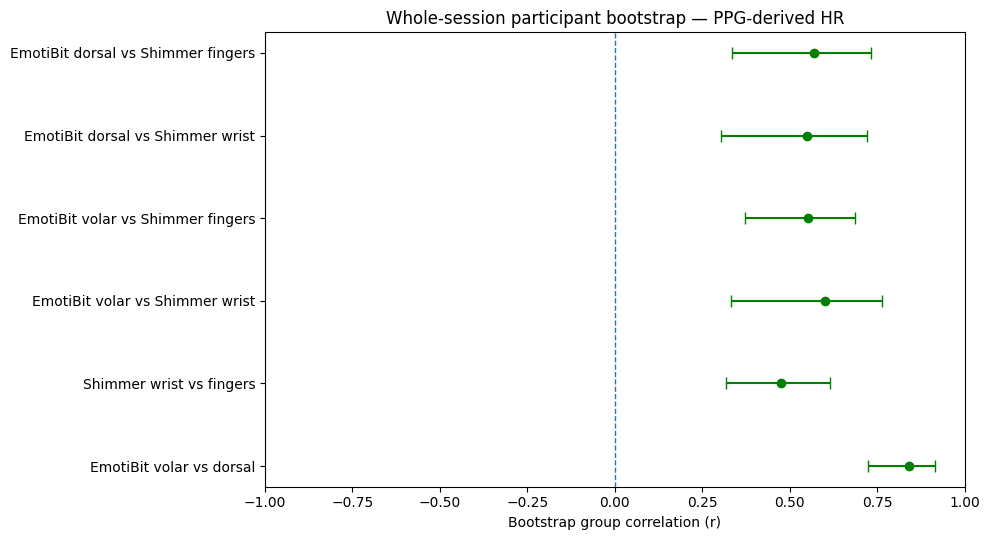

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(OUTPUT_DIR / "whole_session_bootstrap.csv")

comparison_order = [
    "EmotiBit volar vs dorsal",
    "Shimmer wrist vs fingers",
    "EmotiBit volar vs Shimmer wrist",
    "EmotiBit volar vs Shimmer fingers",
    "EmotiBit dorsal vs Shimmer wrist",
    "EmotiBit dorsal vs Shimmer fingers",
]

def plot_group_r(df, signal):
    sub = df[df["signal"] == signal].copy()
    sub["comparison"] = pd.Categorical(
        sub["comparison"],
        categories=comparison_order,
        ordered=True
    )
    sub = sub.sort_values("comparison").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 5.5))

    for i, row in sub.iterrows():
        color = "green" if row["ci_low"] > 0 or row["ci_high"] < 0 else "red"

        ax.hlines(i, row["ci_low"], row["ci_high"], color=color)
        ax.plot(
            [row["ci_low"], row["ci_high"]],
            [i, i],
            linestyle="none",
            marker="|",
            markersize=8,
            color=color,
        )
        ax.plot(row["group_r"], i, marker="o", linestyle="none", color=color)

    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(sub["comparison"])
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Bootstrap group correlation (r)")
    ax.set_title(
        f'Whole-session participant bootstrap — {"EDA" if signal=="Gsr" else "PPG-derived HR"}'
    )

    plt.tight_layout()
    plt.show()

plot_group_r(df, "Gsr")
plot_group_r(df, "Hr")